### **Imports**

In [39]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Optional
from sklearn.datasets import load_breast_cancer, make_circles
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
import time
import xgboost as xgb
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

### **Load data**

In [40]:
# Breast Cancer data
data = load_breast_cancer()
X = data.data
y = data.target

print(f"samples: {X.shape[0]}")
print(f"features: {X.shape[1]}")
print(f"classes: {data.target_names}")

samples: 569
features: 30
classes: ['malignant' 'benign']


### **Task 1**

#### Implementing SVM from scratch

#### Mathematical Formulation <br>For training data $(x_i, y_i)$ where $x_i \in \mathbb{R}^d$ and $y_i \in \{-1, +1\}$, <br>we seek $(w, b)$ that minimize <br>$ {\frac{1}{2}\|w\|^2} $ <br>subject to the constraints <br>$y_i (w^\top x_i + b) \geq 1 \quad \text{for all } i.$ <br>The dual formulation (hard-margin) is: <br>$\max_{\alpha} \sum_{i=1}^n \alpha_i - \frac{1}{2}\sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j y_i y_j x_i^\top x_j$ <br>subject to <br>$\alpha_i \geq 0, \quad \sum_{i=1}^n \alpha_i y_i = 0.$ <br>The optimal parameters are recovered as: <br>$w = \sum_{i=1}^n \alpha_i y_i x_i, \quad b = y_k - w^\top x_k \quad \text{for any support vector } k \text{ with } \alpha_k > 0.$ <br>

In [41]:
@dataclass
class SVMResult:
    """
    Container for the trained SVM model parameters.

    Attributes:
        w (np.ndarray): The normal vector to the hyperplane (Primal weights).
        b (float): The bias term (intercept).
        support_idx (np.ndarray): Indices of the support vectors in the original dataset.
        alphas (np.ndarray): The Lagrange multipliers found by the dual optimization.
    """
    w: np.ndarray
    b: float
    support_idx: np.ndarray
    alphas: np.ndarray

class LinearSVMHardMargin:
    """
    A simplified implementation of the Sequential Minimal Optimization (SMO) algorithm
    for Linear SVM.

    While named 'HardMargin', the inclusion of parameter C allows this to function 
    as a Soft Margin SVM. To approximate a true Hard Margin (enforcing perfect 
    separation), set C to a very large number (e.g., 1e10).

    The algorithm solves the Dual Optimization problem:
        maximize:  sum(alpha) - 0.5 * alpha^T * (Y * Y^T * K) * alpha
        subject to: 0 <= alpha <= C  and  sum(alpha * y) = 0
    """
    def __init__(self, C: float = 1e10, tol: float = 1e-4, max_passes: int = 100, seed: Optional[int] = None):
        """
        Args:
            C (float): Regularization parameter (Box constraint). Large C = Hard Margin.
            tol (float): Numerical tolerance for KKT condition checks.
            max_passes (int): max iterations through the dataset without changing alphas before stopping.
            seed (int): Random seed for the heuristic selection of the second alpha.
        """
        self.C = float(C)
        self.tol = float(tol)
        self.max_passes = int(max_passes)
        self.rng = np.random.default_rng(seed)
        
        # Model attributes placeholders
        self.w_ = None
        self.b_ = None
        self.alphas_ = None
        self.support_idx_ = None

    @staticmethod
    def _kernel_linear(X: np.ndarray) -> np.ndarray:
        """Computes the linear kernel (Gram matrix): K(x, z) = x^T z"""
        return X @ X.T

    def fit(self, X: np.ndarray, y: np.ndarray) -> SVMResult:
        """
        Trains the SVM model using the Simplified SMO algorithm.

        Args:
            X (np.ndarray): Feature matrix of shape (n_samples, n_features).
            y (np.ndarray): Target vector of shape (n_samples,) with values {-1, 1}.

        Returns:
            SVMResult: The fitted model parameters.
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n, d = X.shape

        # Precompute the Gram Matrix K to speed up lookups
        # K[i, j] represents the dot product similarity between sample i and sample j
        K = self._kernel_linear(X)
        
        # Initialize Lagrange multipliers (alphas) and bias (b) to zero
        alphas = np.zeros(n, dtype=float)
        b = 0.0

        # Helper Function 
        # Calculates the model prediction f(x) based on current alphas and b.
        # f(x_i) = sum_j (alpha_j * y_j * K(x_j, x_i)) + b
        def f(i: int) -> float:
            return float(np.sum(alphas * y * K[:, i]) + b)

        passes = 0
        
        # Main SMO Loop 
        # We continue until we make 'max_passes' through the dataset 
        # without making any significant changes to the alphas.
        while passes < self.max_passes:
            num_changed = 0
            # Iterate indices in random order to prevent cycles
            idxs = self.rng.permutation(n)
            
            for i in idxs:
                # 1. Calculate error for the first selected alpha (i)
                # E_i = prediction - target
                E_i = f(i) - y[i]
                
                # 2. Check KKT Conditions
                # The KKT conditions require that for optimal solution:
                #   alpha = 0   => y*f(x) >= 1 (Correctly classified, outside margin)
                #   0 < alpha < C => y*f(x) = 1  (Support vector, on margin)
                #   alpha = C   => y*f(x) <= 1 (Inside margin or misclassified)
                #
                # We define r_i = y_i * E_i (roughly related to margin distance).
                # If conditions are violated, we attempt to optimize alpha_i.
                r_i = y[i] * E_i
                
                if (r_i < -self.tol and alphas[i] < self.C) or \
                   (r_i > self.tol and alphas[i] > 0):

                    # 3. Select second alpha (j) randomly (Simplified SMO heuristic)
                    j = self.rng.integers(0, n)
                    while j == i:
                        j = self.rng.integers(0, n)

                    # Calculate error for second alpha
                    E_j = f(j) - y[j]

                    # Save old values before updating
                    alpha_i_old, alpha_j_old = alphas[i].copy(), alphas[j].copy()

                    # 4. Compute Bounds L and H
                    # We must keep alphas within [0, C] and satisfy the constraint:
                    # y_i * alpha_i + y_j * alpha_j = constant
                    if y[i] != y[j]:
                        L = max(0.0, alphas[j] - alphas[i])
                        H = min(self.C, self.C + alphas[j] - alphas[i])
                    else:
                        L = max(0.0, alphas[i] + alphas[j] - self.C)
                        H = min(self.C, alphas[i] + alphas[j])

                    if L == H:
                        continue

                    # 5. Compute eta (second derivative of objective function)
                    # eta = 2*K(i,j) - K(i,i) - K(j,j)
                    # Note: The standard formula uses the negative of this, 
                    # so here we check if eta < 0 for valid curvature.
                    eta = 2.0 * K[i, j] - K[i, i] - K[j, j]
                    
                    if eta >= -1e-12:
                        # If eta is not negative, the objective function isn't strictly 
                        # convex (linear or flat), making the maximum hard to find analytically.
                        continue

                    # 6. Compute new alpha_j
                    # alpha_j_new = alpha_j_old - y_j * (E_i - E_j) / eta
                    # (Using the negative eta formulation)
                    alpha_j_new = alpha_j_old - y[j] * (E_i - E_j) / eta

                    # 7. Clip alpha_j to bounds [L, H]
                    alpha_j_new = np.clip(alpha_j_new, L, H)

                    # If change is too small, don't bother updating to ensure numerical stability
                    if abs(alpha_j_new - alpha_j_old) < 1e-5:
                        continue

                    # 8. Update alpha_i
                    # To satisfy sum(y*alpha) = 0 constraint
                    alpha_i_new = alpha_i_old + y[i] * y[j] * (alpha_j_old - alpha_j_new)

                    # Store new alphas
                    alphas[i], alphas[j] = alpha_i_new, alpha_j_new

                    # 9. Update threshold b
                    # We compute two possible values for b (b1, b2) based on the new alphas 
                    # forcing the KKT conditions (margin property) to hold.
                    b1 = b - E_i - y[i] * (alpha_i_new - alpha_i_old) * K[i, i] - y[j] * (alpha_j_new - alpha_j_old) * K[i, j]
                    b2 = b - E_j - y[i] * (alpha_i_new - alpha_i_old) * K[i, j] - y[j] * (alpha_j_new - alpha_j_old) * K[j, j]

                    # If an alpha is strictly between 0 and C, the point is a support vector 
                    # exactly on the margin, so that b is valid. If both are on margin, average them.
                    if 0.0 < alpha_i_new < self.C:
                        b = b1
                    elif 0.0 < alpha_j_new < self.C:
                        b = b2
                    else:
                        b = 0.5 * (b1 + b2)

                    num_changed += 1

            # Convergence check logic
            if num_changed == 0:
                passes += 1
            else:
                passes = 0

        # Finalization 
        # Filter out numerical noise for sparsity
        alphas[alphas < self.tol] = 0.0
        
        # Reconstruct Primal Weights w
        # w = sum(alpha_i * y_i * x_i)
        w = (alphas * y) @ X
        
        # Identify Support Vectors
        support_idx = np.where(alphas > self.tol)[0]
        
        # Recompute b one last time averaging over all support vectors for robustness
        if len(support_idx) > 0:
            b_vals = y[support_idx] - X[support_idx] @ w
            b = float(np.mean(b_vals))

        # Save state
        self.w_ = w
        self.b_ = b
        self.alphas_ = alphas
        self.support_idx_ = support_idx

        return SVMResult(w=w, b=b, support_idx=support_idx, alphas=alphas)
    
    def decision_function(self, X: np.ndarray) -> np.ndarray:
        """Computes the raw score (distance to hyperplane) for samples in X."""
        return X @ self.w_ + self.b_

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Classifies samples as +1 or -1 based on the sign of the score."""
        # Returns 1.0 if score >= 0, else -1.0
        return np.where(self.decision_function(X) >= 0.0, 1.0, -1.0)
    
    def plot_fit(self, X: np.ndarray, y: np.ndarray, title: str = "SVM Fit"):
        """
        Visualizes the decision boundary, margins, and support vectors.

        Logic:
            The decision boundary is the line where w . x + b = 0.
            In 2D: w0*x + w1*y + b = 0.
            To plot this, we solve for y:
                y = -(w0*x + b) / w1
            
            The margins are defined by w . x + b = +1 and w . x + b = -1.
                y_margin_pos = -(w0*x + b - 1) / w1
                y_margin_neg = -(w0*x + b + 1) / w1
        """
        if self.w_ is None:
            raise RuntimeError("Model not fitted yet.")

        plt.figure(figsize=(7, 7))
        
        # 1. Scatter Data Points
        plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='blue', label="Class +1")
        plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], c='red', label="Class -1")

        # 2. Highlight Support Vectors (Points with alpha > 0)
        if self.support_idx_ is not None:
            plt.scatter(X[self.support_idx_, 0], X[self.support_idx_, 1],
                        s=150, facecolors="none", edgecolors="k", linewidth=1.5, label="Support Vectors")

        # 3. Draw Hyperplanes
        w = self.w_
        b = self.b_
        
        # Determine reasonable x-axis limits for the plot
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        
        # Case A: Vertical Boundary (w1 is effectively 0)
        # This occurs when the boundary is x = constant
        if abs(w[1]) < 1e-5:
            # w0*x + b = 0  => x = -b/w0
            x_dec = -b / w[0]
            plt.axvline(x=x_dec, color='k', label="Decision Boundary")
            
            # Margins: w0*x + b = +/- 1  => x = (+/- 1 - b) / w0
            plt.axvline(x=(1 - b) / w[0], color='k', linestyle='--', label="Margins")
            plt.axvline(x=(-1 - b) / w[0], color='k', linestyle='--')
            
        # Case B: Standard Line (Slanted or Horizontal)
        else:
            xx = np.linspace(x_min, x_max, 100)
            
            # Decision boundary: w . x + b = 0
            yy = -(w[0] * xx + b) / w[1]
            
            # Upper margin: w . x + b = 1
            yy_up = -(w[0] * xx + b - 1) / w[1]
            
            # Lower margin: w . x + b = -1
            yy_down = -(w[0] * xx + b + 1) / w[1]
            
            plt.plot(xx, yy, "k-", label="Decision Boundary")
            plt.plot(xx, yy_up, "k--", label="Margins")
            plt.plot(xx, yy_down, "k--")

        plt.title(title)
        plt.xlabel("x1")
        plt.ylabel("x2")
        plt.legend(loc="upper right")
        plt.grid(True, alpha=0.3)
        plt.axis("equal") # Essential to visualize the margin distance correctly
        plt.show()

#### Tests

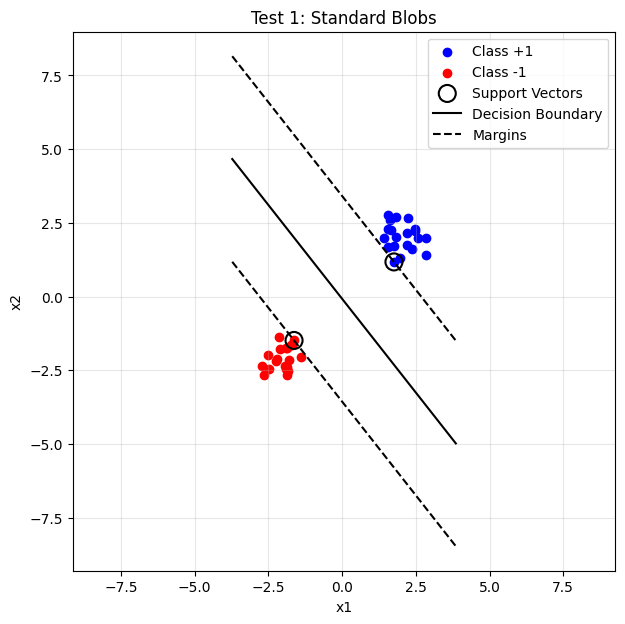

Training Accuracy: 100.00%


In [42]:
# Generate
rng = np.random.default_rng(35)
n = 40
X_pos_generated = rng.normal(loc=[2.0, 2.0], scale=0.4, size=(n // 2, 2))
X_neg_generated = rng.normal(loc=[-2.0, -2.0], scale=0.4, size=(n // 2, 2))
X_generated = np.vstack([X_pos_generated, X_neg_generated])
y_generated = np.hstack([np.ones(X_pos_generated.shape[0]), -np.ones(X_neg_generated.shape[0])])

# Fit & Plot
svm = LinearSVMHardMargin(C=1e10, seed=123)
svm.fit(X_generated, y_generated)
svm.plot_fit(X_generated, y_generated, title="Test 1: Standard Blobs")

# Calculate Accuracy
# We predict on the same data we trained on (Training Accuracy)
predictions = svm.predict(X_generated)
accuracy = np.mean(predictions == y_generated)

print(f"Training Accuracy: {accuracy * 100:.2f}%")

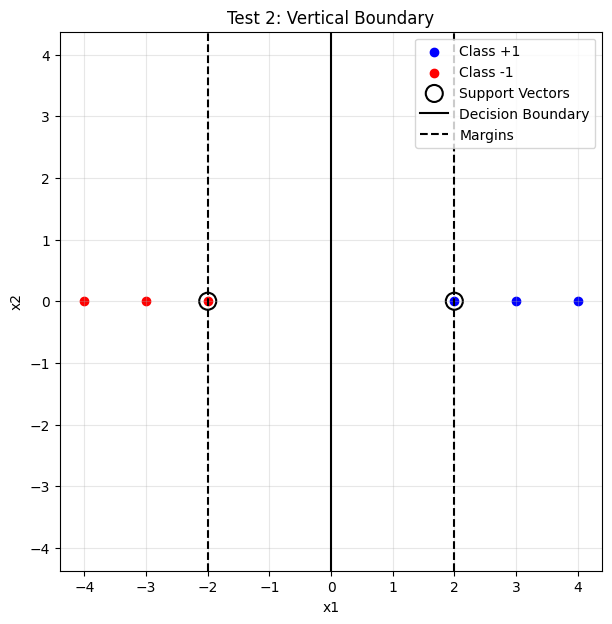

Training Accuracy: 100.00%


In [43]:
# Generate (Points on X-axis only)
X_pos_generated = np.array([[2.0, 0.0], [3.0, 0.0], [4.0, 0.0]])
X_neg_generated = np.array([[-2.0, 0.0], [-3.0, 0.0], [-4.0, 0.0]])
X_generated = np.vstack([X_pos_generated, X_neg_generated])
y_generated = np.hstack([np.ones(len(X_pos_generated)), -np.ones(len(X_neg_generated))])

# Fit & Plot
svm_vert = LinearSVMHardMargin(C=1e10, seed=42)
svm_vert.fit(X_generated, y_generated)
svm_vert.plot_fit(X_generated, y_generated, title="Test 2: Vertical Boundary")

# Calculate Accuracy
# We predict on the same data we trained on (Training Accuracy)
predictions = svm.predict(X_generated)
accuracy = np.mean(predictions == y_generated)

print(f"Training Accuracy: {accuracy * 100:.2f}%")

### **Task 2**

#### Using SVM from scikit-learn

In [44]:
# Train / test split (Breast Cancer)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scalling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
# Building SVM model with linear kernel
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Accuracy score
y_pred = svm_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Accuracy: 0.9737

Classification report:
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



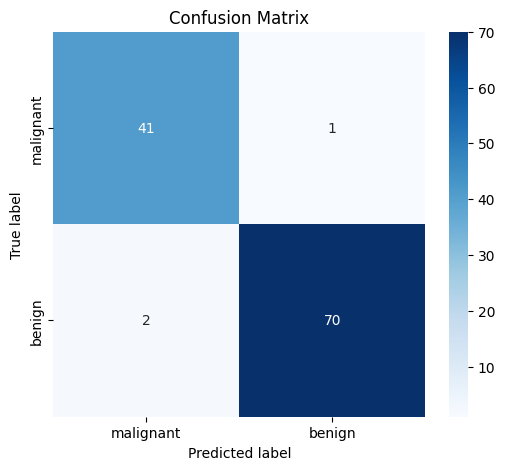

In [46]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=data.target_names, 
            yticklabels=data.target_names)
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

#### Using PCA to visualize high dimentional data seperation (compressing 30 dimensions into one)

Original shape: (569, 30)
PCA shape:      (569, 2)


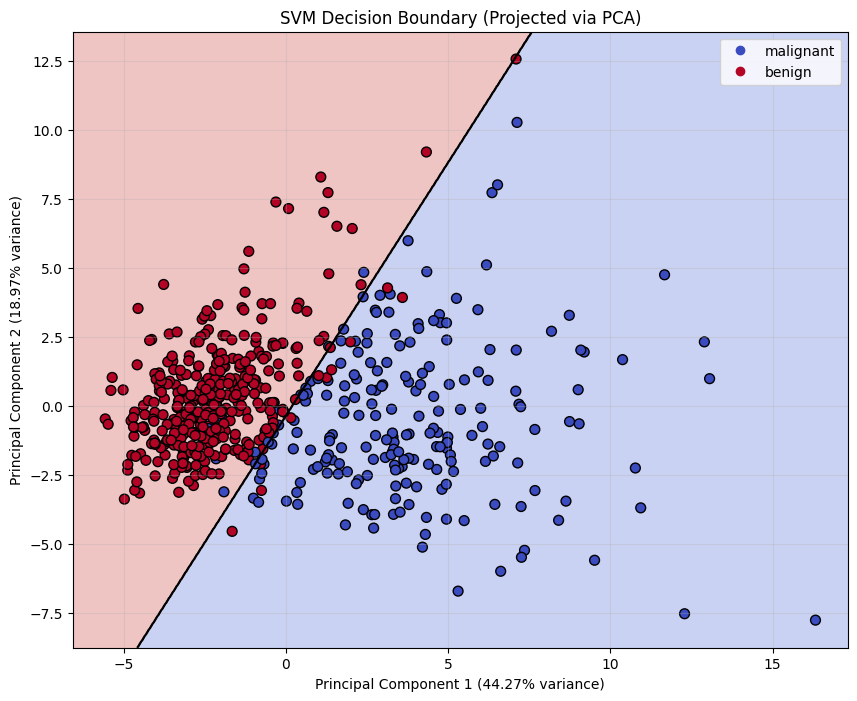

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce 30 features -> 2 features
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Original shape: {X_scaled.shape}") # (569, 30)
print(f"PCA shape:      {X_pca.shape}")    # (569, 2)

# Train a 2D SVM on the PCA data just for visualization
# Note: This is a simplified model of the full 30D model
svm_2d = SVC(kernel='linear', C=1.0)
svm_2d.fit(X_pca, y)

# Visualization Logic
plt.figure(figsize=(10, 8))

# Create a meshgrid to plot the decision boundary
h = 0.02  # Step size
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict for every point in the grid
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot contours
plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
plt.contour(xx, yy, Z, colors='k', levels=[0], linestyles='-') # The line

# Plot the actual data points
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=50)

# Add labels
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
plt.title("SVM Decision Boundary (Projected via PCA)")
plt.legend(handles=scatter.legend_elements()[0], labels=data.target_names.tolist())
plt.grid(alpha=0.3)
plt.show()

### **Task 3**

#### RBF Kernel

In [48]:
# Generate synthetic non-linearly separable data (Circles)
# factor=0.5 means the inner circle is half the size of the outer circle
X_generated, y_generated = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_generated, y_generated, test_size=0.2, random_state=42)

# Train SVM with a Linear Kernel
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

# Train SVM with a Radial Basis Function (RBF/Gaussian) Kernel
# gamma='scale' - it controls the width of the Gaussian bell curve (default).
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


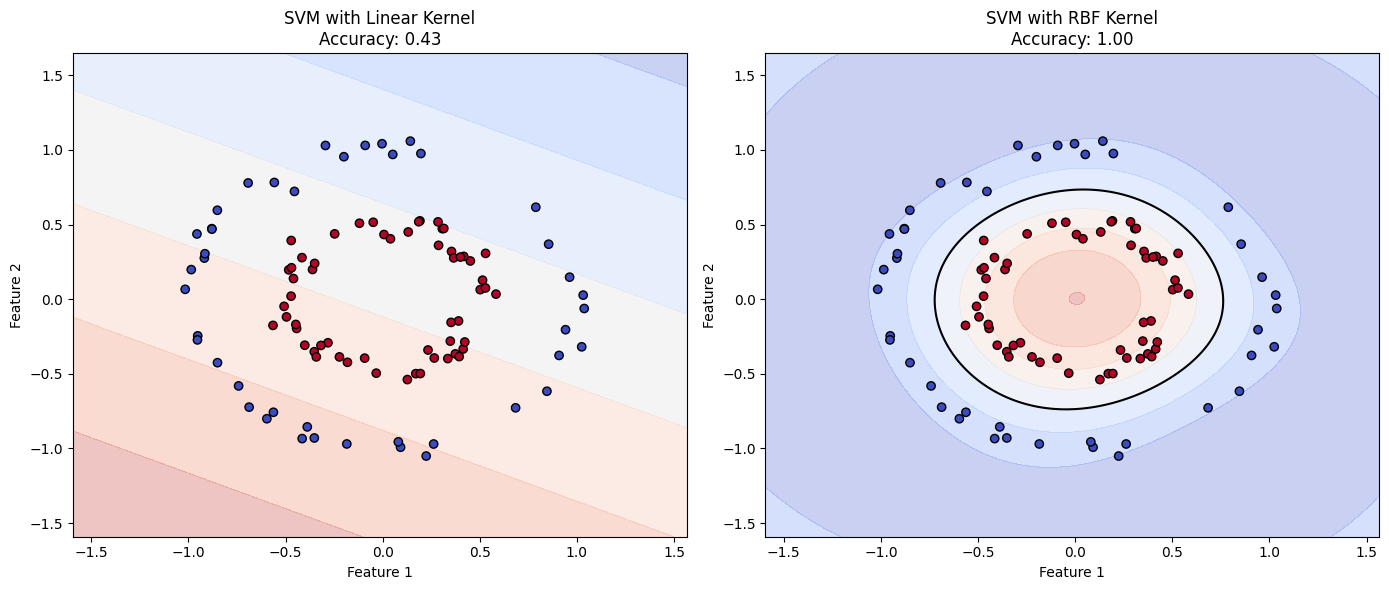

In [49]:
# Visualization logic
def plot_decision_boundary(model, ax, title):
    """Plots the decision boundary using the decision_function for better detail."""
    
    # Create the grid
    h = 0.02
    x_min, x_max = X_generated[:, 0].min() - 0.5, X_generated[:, 0].max() + 0.5
    y_min, y_max = X_generated[:, 1].min() - 0.5, X_generated[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Use decision_function instead of predict
    # This gives us a continuous score (distance from the separator)
    # instead of a hard 0/1 class.
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the color gradient (The "Confidence" of the model)
    # This shows us the 'slope' of the linear model
    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)

    # Explicitly draw the Decision Boundary (The Black Line)
    # This draws a line exactly where the score is 0
    ax.contour(xx, yy, Z, colors='k', levels=[0], linestyles='-')
    
    # Plot the original data points
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, edgecolors='k')
    
    acc = accuracy_score(y_test, model.predict(X_test))
    ax.set_title(f"{title}\nAccuracy: {acc:.2f}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

# Set up the plot area
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Linear SVM
plot_decision_boundary(svm_linear, axes[0], "SVM with Linear Kernel")

# Plot RBF SVM
plot_decision_boundary(svm_rbf, axes[1], "SVM with RBF Kernel")

plt.tight_layout()
plt.show()

#### **Explanation of the results** <br> **1. Linear Kernel (The Failure)** <br> The left plot, the Linear SVM performs poorly. A linear kernel attempts to draw a straight line (or a flat hyperplane) to separate the classes. In the dataset provided, the blue class is surrounded by the red class. There is no single straight line you can draw across the 2D plane that puts all blue points on one side and all red points on the other. <br> **2. RBF Kernel (The Success)** <br> The RBF (Gaussian) SVM creates a perfect circular boundary around the inner cluster. The RBF kernel (Radial Basis Function) measures similarity based on distance. It effectively projects the 2D data into a higher-dimensional (infinite) space. The Trick: imagine lifting the inner circle points up into the air (adding a 3rd dimension based on distance from the center). The inner points become a "mountain" and the outer points remain on the "ground". In this 3D space, the SVM can easily slide a flat sheet (linear hyperplane) between the mountain and the ground. When we project this back down to 2D, that flat sheet looks like a circle.

### **Task 4**

#### Hyperparameter tuning

In [50]:
# Split Data (70% Train, 30% Test) (Breast Cancer)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [51]:
# Default Model (Baseline)

# We manually scale data here for the standalone default model
scaler_default = StandardScaler()
X_train_scaled = scaler_default.fit_transform(X_train)
X_test_scaled = scaler_default.transform(X_test)

# Train with default parameters (C=1.0, gamma='scale', kernel='rbf')
default_model = SVC(kernel='rbf', random_state=42)
default_model.fit(X_train_scaled, y_train)

# Evaluate Baseline
default_pred = default_model.predict(X_test_scaled)
default_acc = accuracy_score(y_test, default_pred)

print(f"Baseline Model (Default Parameters)")
print(f"  Parameters: {default_model.get_params()['C']}, {default_model.get_params()['gamma']}")
print(f"  Test Set Accuracy: {default_acc:.4f}\n")

Baseline Model (Default Parameters)
  Parameters: 1.0, scale
  Test Set Accuracy: 0.9766



In [52]:
# Hyperparameter Tuning with GridSearchCV

# Define a Pipeline
# The pipeline bundles scaling and training. This ensures that during
# Cross-Validation, the scaler is fit ONLY on the training folds, preventing data leakage.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=42))
])

# Define the Parameter Grid
# C: Controls trade-off between decision boundary smoothness and classifying training points correctly.
# Gamma: Controls the influence of a single training point (Low = far, High = close).
param_grid = {
    'svm__C': [0.1, 1, 10, 100, 1000, 10000],
    'svm__gamma': [1, 0.1, 0.01, 0.001, 0.0001, 0.00001]
}

# Setup GridSearchCV
# cv=5 means 5-fold Cross-Validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Run the search
# Note: We pass unscaled X_train because the Pipeline handles scaling internally
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'svm__C': [0.1, 1, ...], 'svm__gamma': [1, 0.1, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [53]:
# Evaluation & Comparison

# Get the best model
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

# Predict using the best model
tuned_pred = best_model.predict(X_test) # Pipeline scales X_test automatically
tuned_acc = accuracy_score(y_test, tuned_pred)

print(f"\nTuned Model (GridSearchCV)")
print(f"  Best Parameters found: C={best_params['svm__C']}, Gamma={best_params['svm__gamma']}")
print(f"  Test Set Accuracy: {tuned_acc:.4f}")

print(f"\nImprovement: {(tuned_acc - default_acc) * 100:.2f} percentage points")


Tuned Model (GridSearchCV)
  Best Parameters found: C=10, Gamma=0.001
  Test Set Accuracy: 0.9708

Improvement: -0.58 percentage points


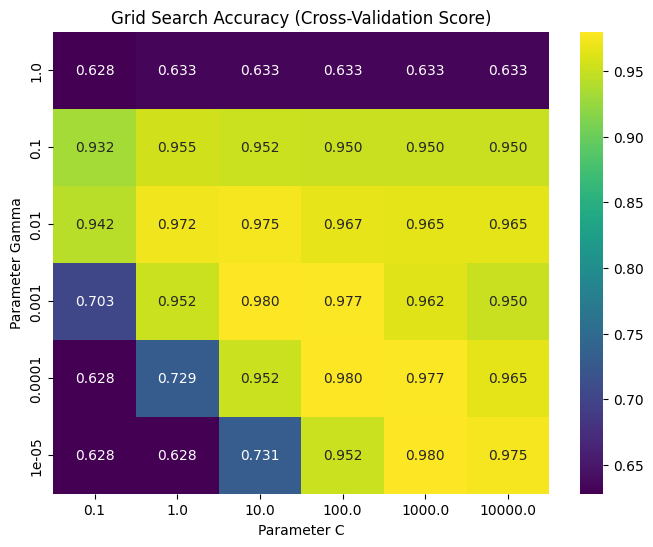

In [54]:
# Visualization of the Grid Search

# Extract results into a DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)
# Pivot the data for heatmap (C vs Gamma)
heatmap_data = results_df.pivot(index='param_svm__gamma', columns='param_svm__C', values='mean_test_score')

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='viridis')
plt.title('Grid Search Accuracy (Cross-Validation Score)')
plt.xlabel('Parameter C')
plt.ylabel('Parameter Gamma')
# Invert Y axis so smallest gamma is at bottom
plt.gca().invert_yaxis()
plt.show()

#### Worse accuracy of the tuned model might be a result of overfitting.

### **Task 5**

#### LIghtGBM vs XGBoost comparison on Breast cancer dataset

In [55]:
# Prepare Data (Breast cancer)
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Clean column names for LightGBM
X.columns = [c.replace(' ', '_') for c in X.columns]

# Constants
N_ROUNDS = 100

# Storage
results = {
    'xgb': {'times': [], 'accs': []},
    'lgb': {'times': [], 'accs': []}
}

In [56]:
# Main Loop
for i in range(N_ROUNDS):
    # Dynamic split based on i
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

    # --- XGBoost ---
    start = time.time()
    # FIX: Removed 'use_label_encoder'
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        eval_metric='logloss',
        n_jobs=1,
        random_state=42
    )
    xgb_model.fit(X_train, y_train)
    xgb_time = time.time() - start
    xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test))

    results['xgb']['times'].append(xgb_time)
    results['xgb']['accs'].append(xgb_acc)

    # LightGBM
    start = time.time()
    lgb_model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        verbosity=-1, 
        n_jobs=1, 
        random_state=42
    )
    lgb_model.fit(X_train, y_train)
    lgb_time = time.time() - start
    lgb_acc = accuracy_score(y_test, lgb_model.predict(X_test))

    results['lgb']['times'].append(lgb_time)
    results['lgb']['accs'].append(lgb_acc)

    # Progress bar
    if (i + 1) % 10 == 0:
        print(f"Completed {i + 1}/{N_ROUNDS} rounds...")

Completed 10/100 rounds...
Completed 20/100 rounds...
Completed 30/100 rounds...
Completed 40/100 rounds...
Completed 50/100 rounds...
Completed 60/100 rounds...
Completed 70/100 rounds...
Completed 80/100 rounds...
Completed 90/100 rounds...
Completed 100/100 rounds...


In [57]:
# Statistics
def get_stats(data_list):
    return {
        'avg': np.mean(data_list),
        'min': np.min(data_list),
        'max': np.max(data_list)
    }

xgb_stats_t = get_stats(results['xgb']['times'])
xgb_stats_a = get_stats(results['xgb']['accs'])
lgb_stats_t = get_stats(results['lgb']['times'])
lgb_stats_a = get_stats(results['lgb']['accs'])

# Display
print("\n" + "="*65)
print(f"{'METRIC':<15} | {'XGBOOST':<22} | {'LIGHTGBM':<22}")
print("="*65)

# Time Stats
print(f"{'Avg Time (s)':<15} | {xgb_stats_t['avg']:.6f}               | {lgb_stats_t['avg']:.6f}")
print(f"{'Best Time (s)':<15} | {xgb_stats_t['min']:.6f}               | {lgb_stats_t['min']:.6f}")
print(f"{'Worst Time (s)':<15} | {xgb_stats_t['max']:.6f}               | {lgb_stats_t['max']:.6f}")
print("-" * 65)

# Accuracy Stats
print(f"{'Avg Accuracy':<15} | {xgb_stats_a['avg']:.4f}               | {lgb_stats_a['avg']:.4f}")
print(f"{'Best Accuracy':<15} | {xgb_stats_a['max']:.4f}               | {lgb_stats_a['max']:.4f}")
print(f"{'Worst Accuracy':<15} | {xgb_stats_a['min']:.4f}               | {lgb_stats_a['min']:.4f}")
print("="*65)

speedup = xgb_stats_t['avg'] / lgb_stats_t['avg']
print(f"\nCONCLUSION: LightGBM is on average {speedup:.2f}x faster than XGBoost.")


METRIC          | XGBOOST                | LIGHTGBM              
Avg Time (s)    | 0.133841               | 0.102265
Best Time (s)   | 0.115854               | 0.086517
Worst Time (s)  | 0.167431               | 0.133292
-----------------------------------------------------------------
Avg Accuracy    | 0.9652               | 0.9661
Best Accuracy   | 1.0000               | 1.0000
Worst Accuracy  | 0.9123               | 0.9211

CONCLUSION: LightGBM is on average 1.31x faster than XGBoost.


#### LightGBM introduced key innovations compared to XGBoost:

#### 1. GOSS <br>This is the main differentiator. XGBoost does not implement GOSS. XGBoost uses standard Random Subsampling (controlled by the subsample parameter), which selects rows randomly regardless of how "hard" or "easy" they are to classify. LightGBM's GOSS intelligently keeps all "hard" data points (large gradients) and only samples a small percentage of "easy" points. This makes LightGBM mathematically more efficient per iteration on large datasets.


#### 2. EFB - Exclusive Feature Bundling <br> LightGBM bundles mutually exclusive features (features that are never non-zero at the same time, common in sparse data) into a single feature. XGBoost handles sparse data efficiently, but it does not perform this explicit dimensionality reduction step.

### **Task 6**

In [58]:
# Initialize the Model
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

# Define the Cross-Validation Strategy
# StratifiedKFold ensures the class distribution (malignant/benign) 
# is preserved in every fold.
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("Running Stratified K-Fold Cross-Validation (k=10)...")
print("-" * 50)

# Perform Cross-Validation on Breast Cancer dataset
# This runs the training and evaluation 10 times.
scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='accuracy')

# Report Results
for i, score in enumerate(scores):
    print(f"Fold {i+1}: {score:.4f}")

print("-" * 50)
print(f"Mean Accuracy: {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")
print("-" * 50)

Running Stratified K-Fold Cross-Validation (k=10)...
--------------------------------------------------
Fold 1: 0.9649
Fold 2: 0.9649
Fold 3: 0.9649
Fold 4: 0.8947
Fold 5: 0.9649
Fold 6: 0.9825
Fold 7: 1.0000
Fold 8: 0.9474
Fold 9: 0.9298
Fold 10: 1.0000
--------------------------------------------------
Mean Accuracy: 0.9614
Standard Deviation: 0.0302
--------------------------------------------------


#### **A single Train/Test split carries a significant risk**: <br>**The "Lucky Split" Problem**: You might accidentally randomly select the "easiest" 20% of data points for your test set. Your model will report 99% accuracy, but when deployed to production, it fails. This gives you false confidence. <br> **The "Unlucky Split" Problem**: Conversely, your test set might contain all the weird outliers. Your model reports low accuracy, and you scrap a model that was actually quite good.<br> **Data Efficiency (Crucial for small datasets)**: In the Breast Cancer dataset (only 569 records), setting aside 20% (114 records) strictly for testing means the model never learns from those records. Cross-validation ensures that every single data point is used for both training (in k−1 folds) and validation (in 1 fold) at some point.<br>**The lack of Stability Measurement (Standard Deviation)**: The code above calculates the Standard Deviation of the scores. Low Std Dev (e.g., 0.01): The model is stable; it works equally well on any subset of data. High Std Dev (e.g., 0.08): The model is unstable; it is overfitting to specific patterns in specific folds. A single train/test split cannot tell you this.